# Portfolio Growth Report

**Что делает этот ноутбук:**  
Читает лучшие параметры по каждому таргету из `results/grid_search/best_by_target.csv`,  
заново прогоняет пайплайн и строит кривые роста портфеля ($10 000 начальный капитал).

> **Примечание:** Грид-сёрч был завершён для 5 таргетов на рынок.  
> Чтобы добавить оставшиеся 5, запустите `scripts/02_grid_search.py --market <market>` и обновите `best_by_target.csv`.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
SRC_ROOT = PROJECT_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
from dataclasses import replace

from sarb.run import (
    RunConfig,
    load_market_prices,
    load_run_config,
    run_unified_pipeline,
)

# ---------- глобальные настройки ----------
INITIAL_CAPITAL = 10_000.0
BEST_BY_TARGET_PATH = PROJECT_ROOT / "results" / "grid_search" / "best_by_target.csv"

# Стиль графиков
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/mikhailchekunov/PycharmProjects/replication-portfolio-arbitrage-mvp


## 1. Загрузка лучших параметров из грид-сёрча

In [2]:
best_params = pd.read_csv(BEST_BY_TARGET_PATH)

display_cols = [
    "market", "target",
    "rebalance_frequency", "entry_z", "exit_z",
    "sharpe_ratio", "annualized_return", "annualized_volatility",
    "max_drawdown", "total_return",
]

styled = (
    best_params[display_cols]
    .style
    .format({
        "sharpe_ratio": "{:.3f}",
        "annualized_return": "{:.1%}",
        "annualized_volatility": "{:.1%}",
        "max_drawdown": "{:.1%}",
        "total_return": "{:.1%}",
    })
    .background_gradient(subset=["sharpe_ratio"], cmap="RdYlGn")
    .set_caption("Лучшие параметры по таргету (по Sharpe Ratio)")
)
styled

,market,target,rebalance_frequency,entry_z,exit_z,sharpe_ratio,annualized_return,annualized_volatility,max_drawdown,total_return
0,crypto,BNB,24,3.000000,0.000000,1.819,119.0%,65.4%,-63.2%,9615.5%
1,crypto,BTC,72,2.500000,0.000000,2.104,100.0%,47.5%,-32.5%,5611.1%
2,crypto,ETH,72,3.000000,0.000000,2.224,126.4%,56.8%,-48.7%,11698.9%
3,crypto,SOL,24,2.000000,0.000000,2.023,220.2%,108.8%,-77.2%,50482.6%
4,crypto,XRP,24,2.000000,0.250000,1.405,106.2%,75.6%,-66.8%,6727.9%
5,russia,AFKS,5,3.000000,0.000000,1.587,60.5%,38.1%,-30.9%,15990.1%
6,russia,AFLT,5,2.500000,0.000000,1.096,41.5%,37.9%,-36.9%,4067.9%
7,russia,CHMF,21,2.500000,0.250000,1.092,20.7%,19.0%,-38.7%,653.8%
8,russia,GAZP,21,2.000000,0.000000,1.463,56.6%,38.7%,-27.2%,12276.0%
9,russia,LKOH,10,1.000000,0.500000,0.865,19.1%,22.1%,-30.5%,553.6%


## 2. Вспомогательные функции

In [4]:
def prepare_prices(market: str, prices: pd.DataFrame) -> pd.DataFrame:
    """Россия: дропаем строки с NaN (требование пайплайна)."""
    if market == "russia":
        return prices.dropna(how="any")
    return prices


def resolve_ticker(prices: pd.DataFrame, target: str) -> str:
    """BRK.B → BRK-B если нужно."""
    if target in prices.columns:
        return target
    alt = target.replace(".", "-")
    if alt in prices.columns:
        return alt
    raise KeyError(f"Target {target!r} not found in prices")


def reconstruct_run_config(row: pd.Series) -> RunConfig:
    """Восстанавливаем RunConfig из строки CSV: базовый конфиг + лучшие параметры."""
    base = load_run_config(str(row["market"]))
    return replace(
        base,
        train_window=int(row["train_window"]),
        rebalance_frequency=int(row["rebalance_frequency"]),
        entry_z=float(row["entry_z"]),
        exit_z=float(row["exit_z"]),
    )


def run_best_pipeline(row: pd.Series, prices: pd.DataFrame):
    """Запускаем полный пайплайн с лучшими параметрами."""
    target = resolve_ticker(prices, str(row["target"]))
    universe = [s.strip() for s in str(row["universe_assets"]).split(",")]
    run_config = reconstruct_run_config(row)
    return run_unified_pipeline(
        prices,
        target=target,
        universe=universe,
        run_config=run_config,
    )


print("Вспомогательные функции определены.")

Вспомогательные функции определены.


## 3. Прогон пайплайна для всех рынков и таргетов

⏳ Ожидаемое время: ~1–2 мин для USA/Russia, ~5–10 мин для крипты (часовые данные).

In [5]:
import time

pipeline_results = {}  # (market, target) -> UnifiedPipelineResult

for market in ["usa", "russia", "crypto"]:
    t0 = time.time()
    print(f"\n{'='*50}")
    print(f"Загружаем цены: {market.upper()}")
    raw_prices = load_market_prices(market)
    prices = prepare_prices(market, raw_prices)
    print(f"  Цены загружены: {prices.shape[0]} строк × {prices.shape[1]} активов")

    market_rows = best_params[best_params["market"] == market]
    for _, row in market_rows.iterrows():
        target = row["target"]
        print(f"  Запуск [{market}/{target}]... ", end="", flush=True)
        t1 = time.time()
        try:
            result = run_best_pipeline(row, prices)
            pipeline_results[(market, target)] = result
            m = result.backtest.metrics
            elapsed = time.time() - t1
            print(
                f"Sharpe={m.sharpe_ratio:.3f} | "
                f"Return={m.total_return*100:.1f}% | "
                f"MDD={m.max_drawdown*100:.1f}% "
                f"[{elapsed:.1f}s]"
            )
        except Exception as exc:
            print(f"ОШИБКА: {exc}")

    total = time.time() - t0
    print(f"  {market.upper()} готов за {total:.1f}s")

print(f"\n✓ Пайплайн завершён: {len(pipeline_results)} таргетов обработано.")


Загружаем цены: USA
  Цены загружены: 2514 строк × 142 активов
  Запуск [usa/AAPL]... Sharpe=0.830 | Return=479.7% | MDD=-29.0% [2.7s]
  Запуск [usa/AMZN]... Sharpe=0.915 | Return=470.4% | MDD=-28.9% [0.3s]
  Запуск [usa/BRK.B]... Sharpe=1.164 | Return=100.4% | MDD=-4.1% [1.4s]
  Запуск [usa/MSFT]... Sharpe=0.818 | Return=380.1% | MDD=-31.8% [0.7s]
  Запуск [usa/NVDA]... Sharpe=1.244 | Return=4064.7% | MDD=-35.9% [0.6s]
  USA готов за 5.9s

Загружаем цены: RUSSIA
  Цены загружены: 2959 строк × 26 активов
  Запуск [russia/AFKS]... Sharpe=1.587 | Return=15990.1% | MDD=-30.9% [2.6s]
  Запуск [russia/AFLT]... Sharpe=1.096 | Return=4067.9% | MDD=-36.9% [2.6s]
  Запуск [russia/CHMF]... Sharpe=1.092 | Return=653.8% | MDD=-38.7% [0.7s]
  Запуск [russia/GAZP]... Sharpe=1.463 | Return=12276.0% | MDD=-27.2% [0.7s]
  Запуск [russia/LKOH]... Sharpe=0.865 | Return=553.6% | MDD=-30.5% [1.4s]
  RUSSIA готов за 8.0s

Загружаем цены: CRYPTO
  Цены загружены: 52573 строк × 43 активов
  Запуск [crypto/BN

## 4. Функция построения графика роста портфеля

In [6]:
PALETTE = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
    "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf",
]


def plot_market_equity_curves(
    pipeline_results: dict,
    market: str,
    title: str,
    initial_capital: float = INITIAL_CAPITAL,
    figsize: tuple = (14, 6),
) -> plt.Figure:
    market_items = sorted(
        [(k, v) for k, v in pipeline_results.items() if k[0] == market],
        key=lambda x: -x[1].backtest.metrics.sharpe_ratio,
    )
    if not market_items:
        print(f"Нет данных для рынка: {market}")
        return None

    fig, ax = plt.subplots(figsize=figsize)

    for i, ((mkt, target), result) in enumerate(market_items):
        equity = result.backtest.equity_curve * initial_capital
        m = result.backtest.metrics
        rc = result.run_config

        label = (
            f"{target}  "
            f"Sharpe={m.sharpe_ratio:.2f}  "
            f"Ret={m.total_return*100:.0f}%  "
            f"MDD={m.max_drawdown*100:.0f}%  "
            f"[entry={rc.entry_z}/exit={rc.exit_z}, reb={rc.rebalance_frequency}]"
        )
        ax.plot(
            equity.index,
            equity,
            label=label,
            linewidth=1.6,
            color=PALETTE[i % len(PALETTE)],
            alpha=0.9,
        )

    ax.axhline(
        initial_capital,
        color="black",
        linestyle="--",
        linewidth=0.9,
        alpha=0.4,
        label=f"Initial ${initial_capital:,.0f}",
    )

    ax.set_title(title, fontsize=14, fontweight="bold", pad=12)
    ax.set_ylabel("Portfolio Value ($)", fontsize=11)
    ax.set_xlabel("Date", fontsize=11)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.legend(
        loc="upper left",
        fontsize=8,
        framealpha=0.92,
        borderpad=0.8,
        labelspacing=0.4,
    )
    fig.tight_layout()
    return fig


print("Функция построения графиков готова.")

Функция построения графиков готова.


---
## 5. США (USA Market)

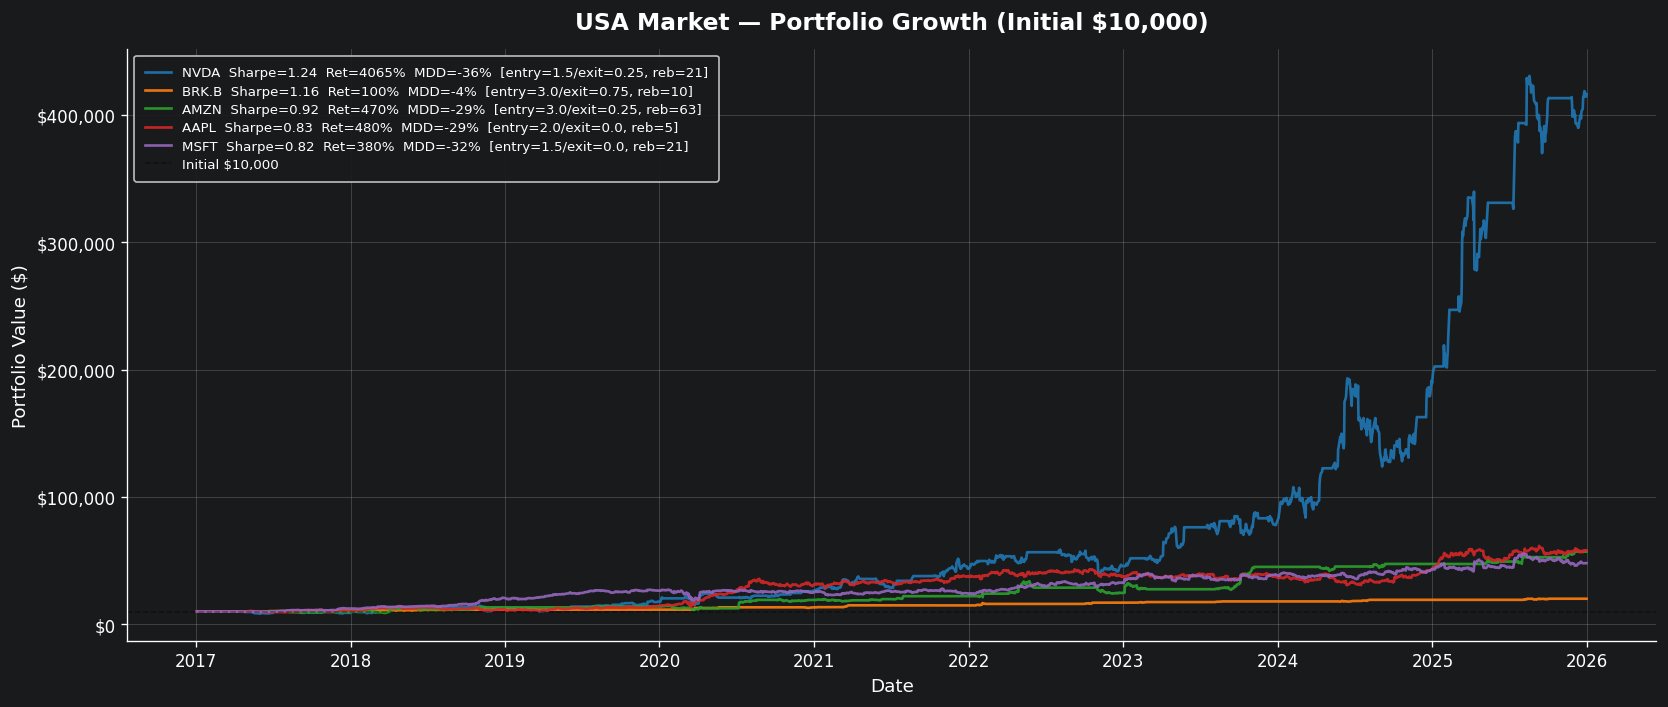

In [7]:
fig_usa = plot_market_equity_curves(
    pipeline_results,
    market="usa",
    title="USA Market — Portfolio Growth (Initial $10,000)",
)
plt.show()

In [8]:
def metrics_table(pipeline_results: dict, market: str) -> pd.DataFrame:
    rows = []
    for (mkt, target), result in sorted(
        pipeline_results.items(),
        key=lambda x: -x[1].backtest.metrics.sharpe_ratio,
    ):
        if mkt != market:
            continue
        m = result.backtest.metrics
        rc = result.run_config
        equity = result.backtest.equity_curve * INITIAL_CAPITAL
        rows.append({
            "Target": target,
            "Final Value ($)": f"${equity.iloc[-1]:,.0f}",
            "Total Return": m.total_return,
            "Ann. Return": m.annualized_return,
            "Ann. Vol": m.annualized_volatility,
            "Sharpe": m.sharpe_ratio,
            "Max Drawdown": m.max_drawdown,
            "# Trades": m.number_of_trades,
            "Hit Rate": m.hit_rate,
            "entry_z / exit_z": f"{rc.entry_z} / {rc.exit_z}",
            "Rebalance": rc.rebalance_frequency,
        })
    df = pd.DataFrame(rows)
    return (
        df.style
        .format({
            "Total Return": "{:.1%}",
            "Ann. Return": "{:.1%}",
            "Ann. Vol": "{:.1%}",
            "Sharpe": "{:.3f}",
            "Max Drawdown": "{:.1%}",
            "Hit Rate": "{:.1%}",
        })
        .background_gradient(subset=["Sharpe"], cmap="RdYlGn")
        .background_gradient(subset=["Max Drawdown"], cmap="RdYlGn_r")
    )

metrics_table(pipeline_results, "usa")

,Target,Final Value ($),Total Return,Ann. Return,Ann. Vol,Sharpe,Max Drawdown,# Trades,Hit Rate,entry_z / exit_z,Rebalance
0,NVDA,"$416,468",4064.7%,51.5%,41.4%,1.244,-35.9%,105,53.5%,1.5 / 0.25,21
1,BRK.B,"$20,041",100.4%,8.1%,6.9%,1.164,-4.1%,32,61.5%,3.0 / 0.75,10
2,AMZN,"$57,042",470.4%,21.4%,23.4%,0.915,-28.9%,41,51.7%,3.0 / 0.25,63
3,AAPL,"$57,965",479.7%,21.6%,26.1%,0.830,-29.0%,31,53.4%,2.0 / 0.0,5
4,MSFT,"$48,010",380.1%,19.1%,23.4%,0.818,-31.8%,40,51.5%,1.5 / 0.0,21


---
## 6. Россия (Russia Market)

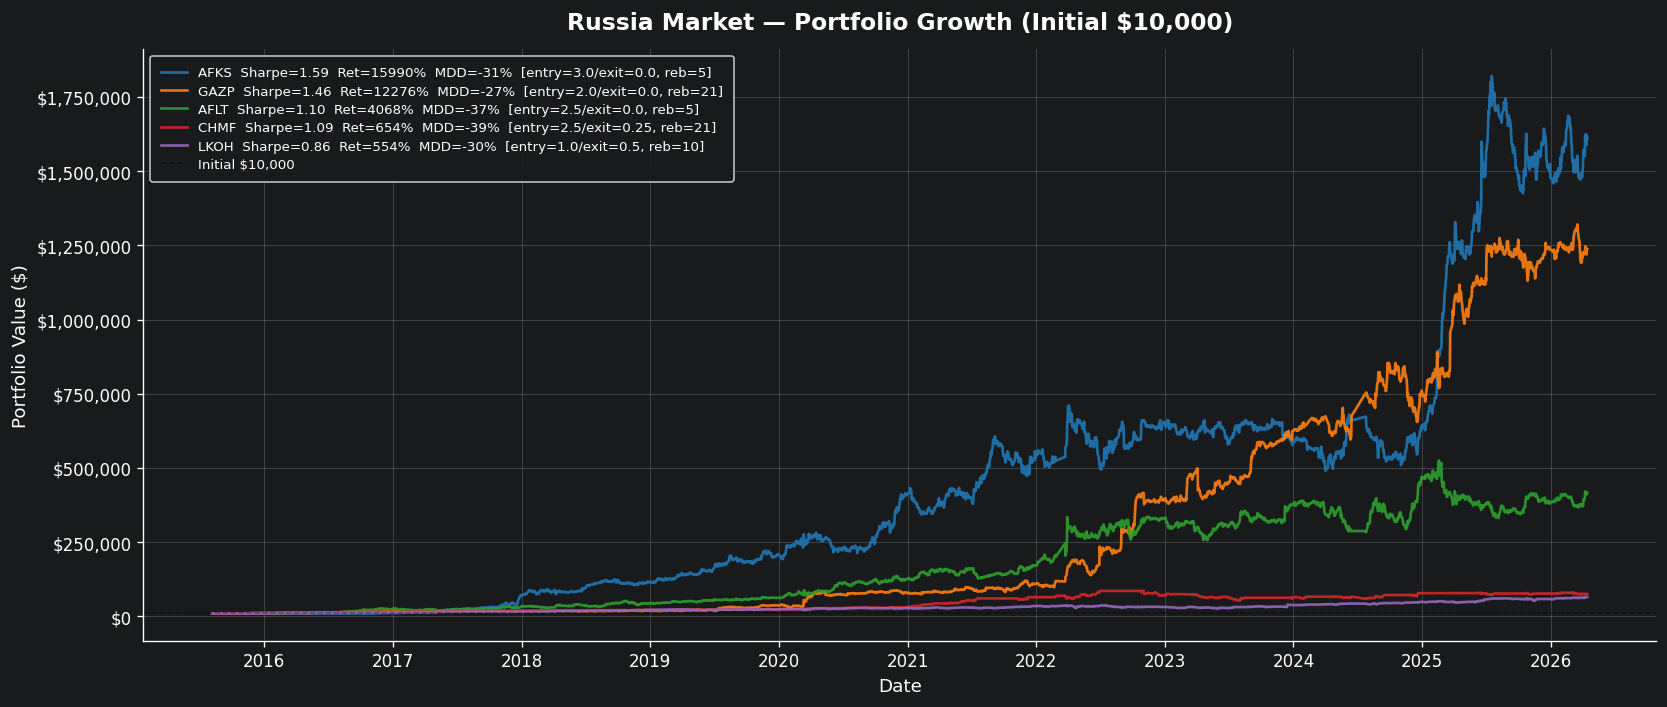

In [9]:
fig_russia = plot_market_equity_curves(
    pipeline_results,
    market="russia",
    title="Russia Market — Portfolio Growth (Initial $10,000)",
)
plt.show()

In [10]:
metrics_table(pipeline_results, "russia")

,Target,Final Value ($),Total Return,Ann. Return,Ann. Vol,Sharpe,Max Drawdown,# Trades,Hit Rate,entry_z / exit_z,Rebalance
0,AFKS,"$1,609,005",15990.1%,60.5%,38.1%,1.587,-30.9%,21,53.5%,3.0 / 0.0,5
1,GAZP,"$1,237,604",12276.0%,56.6%,38.7%,1.463,-27.2%,40,51.9%,2.0 / 0.0,21
2,AFLT,"$416,795",4067.9%,41.5%,37.9%,1.096,-36.9%,25,52.5%,2.5 / 0.0,5
3,CHMF,"$75,384",653.8%,20.7%,19.0%,1.092,-38.7%,70,53.5%,2.5 / 0.25,21
4,LKOH,"$65,364",553.6%,19.1%,22.1%,0.865,-30.5%,226,52.8%,1.0 / 0.5,10


---
## 7. Крипто (Crypto Market)

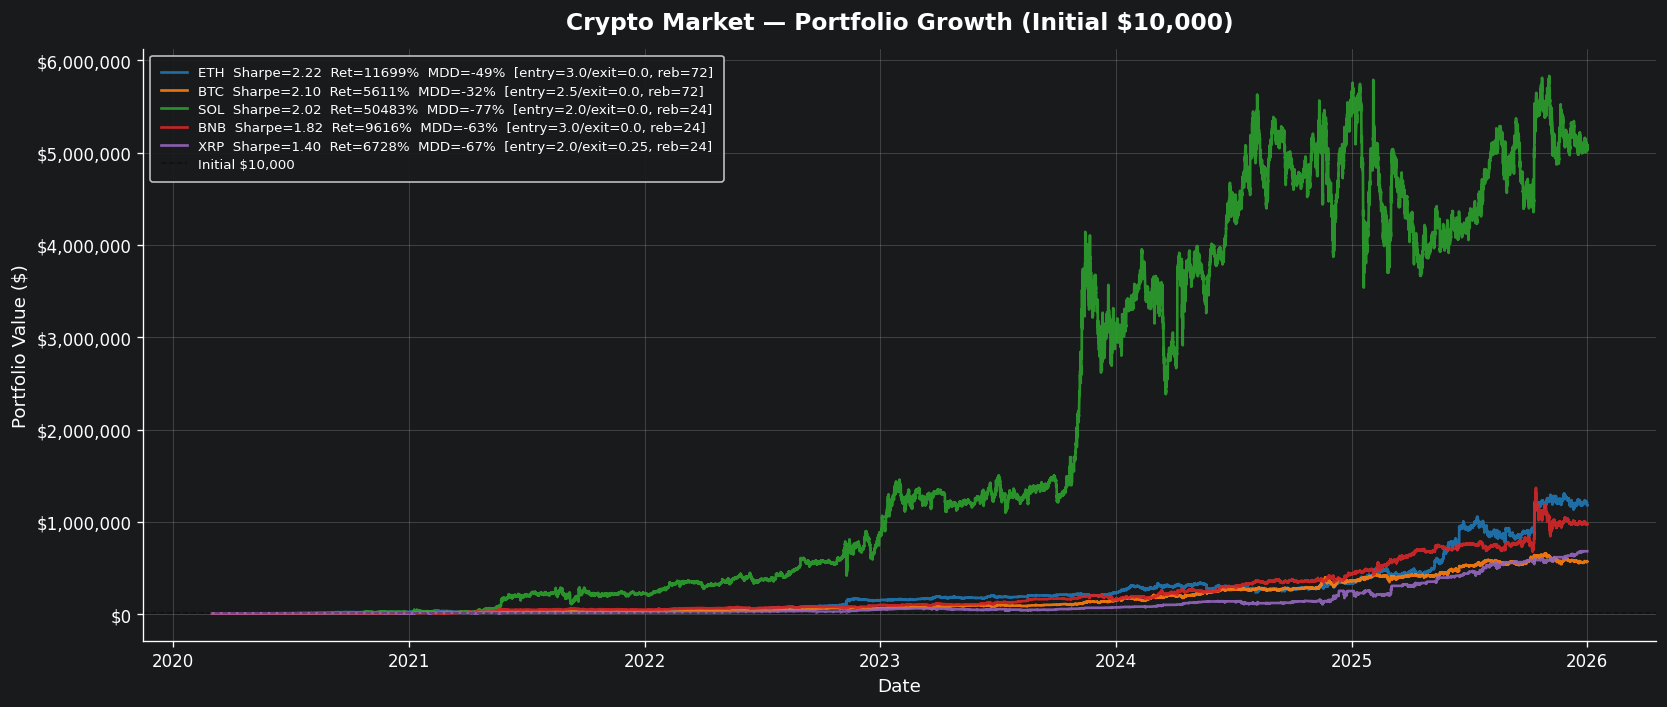

In [11]:
fig_crypto = plot_market_equity_curves(
    pipeline_results,
    market="crypto",
    title="Crypto Market — Portfolio Growth (Initial $10,000)",
    figsize=(14, 6),
)
plt.show()

In [12]:
metrics_table(pipeline_results, "crypto")

,Target,Final Value ($),Total Return,Ann. Return,Ann. Vol,Sharpe,Max Drawdown,# Trades,Hit Rate,entry_z / exit_z,Rebalance
0,ETH,"$1,179,887",11698.9%,126.4%,56.8%,2.224,-48.7%,49,50.3%,3.0 / 0.0,72
1,BTC,"$571,114",5611.1%,100.0%,47.5%,2.104,-32.5%,84,50.4%,2.5 / 0.0,72
2,SOL,"$5,058,258",50482.6%,220.2%,108.8%,2.023,-77.2%,106,50.7%,2.0 / 0.0,24
3,BNB,"$971,551",9615.5%,119.0%,65.4%,1.819,-63.2%,51,50.9%,3.0 / 0.0,24
4,XRP,"$682,789",6727.9%,106.2%,75.6%,1.405,-66.8%,419,51.6%,2.0 / 0.25,24


---
## 8. Сводная таблица по всем рынкам

In [13]:
summary_rows = []
for (market, target), result in sorted(
    pipeline_results.items(),
    key=lambda x: (x[0][0], -x[0][1].backtest.metrics.sharpe_ratio) if False else (x[0][0], x[0][1]),
):
    m = result.backtest.metrics
    rc = result.run_config
    equity = result.backtest.equity_curve * INITIAL_CAPITAL
    summary_rows.append({
        "Market": market.upper(),
        "Target": target,
        "Final Value ($)": equity.iloc[-1],
        "Total Return": m.total_return,
        "Ann. Return": m.annualized_return,
        "Ann. Vol": m.annualized_volatility,
        "Sharpe": m.sharpe_ratio,
        "Max Drawdown": m.max_drawdown,
        "# Trades": m.number_of_trades,
        "Hit Rate": m.hit_rate,
    })

summary_df = pd.DataFrame(summary_rows)

(
    summary_df.style
    .format({
        "Final Value ($)": "${:,.0f}",
        "Total Return": "{:.1%}",
        "Ann. Return": "{:.1%}",
        "Ann. Vol": "{:.1%}",
        "Sharpe": "{:.3f}",
        "Max Drawdown": "{:.1%}",
        "Hit Rate": "{:.1%}",
    })
    .background_gradient(subset=["Sharpe"], cmap="RdYlGn")
    .background_gradient(subset=["Max Drawdown"], cmap="RdYlGn_r")
    .background_gradient(subset=["Final Value ($)"], cmap="Blues")
    .set_caption("Сводная таблица: все рынки и таргеты")
)

,Market,Target,Final Value ($),Total Return,Ann. Return,Ann. Vol,Sharpe,Max Drawdown,# Trades,Hit Rate
0,CRYPTO,BNB,"$971,551",9615.5%,119.0%,65.4%,1.819,-63.2%,51,50.9%
1,CRYPTO,BTC,"$571,114",5611.1%,100.0%,47.5%,2.104,-32.5%,84,50.4%
2,CRYPTO,ETH,"$1,179,887",11698.9%,126.4%,56.8%,2.224,-48.7%,49,50.3%
3,CRYPTO,SOL,"$5,058,258",50482.6%,220.2%,108.8%,2.023,-77.2%,106,50.7%
4,CRYPTO,XRP,"$682,789",6727.9%,106.2%,75.6%,1.405,-66.8%,419,51.6%
5,RUSSIA,AFKS,"$1,609,005",15990.1%,60.5%,38.1%,1.587,-30.9%,21,53.5%
6,RUSSIA,AFLT,"$416,795",4067.9%,41.5%,37.9%,1.096,-36.9%,25,52.5%
7,RUSSIA,CHMF,"$75,384",653.8%,20.7%,19.0%,1.092,-38.7%,70,53.5%
8,RUSSIA,GAZP,"$1,237,604",12276.0%,56.6%,38.7%,1.463,-27.2%,40,51.9%
9,RUSSIA,LKOH,"$65,364",553.6%,19.1%,22.1%,0.865,-30.5%,226,52.8%


---
## 9. Объединённый график: лучший таргет с каждого рынка

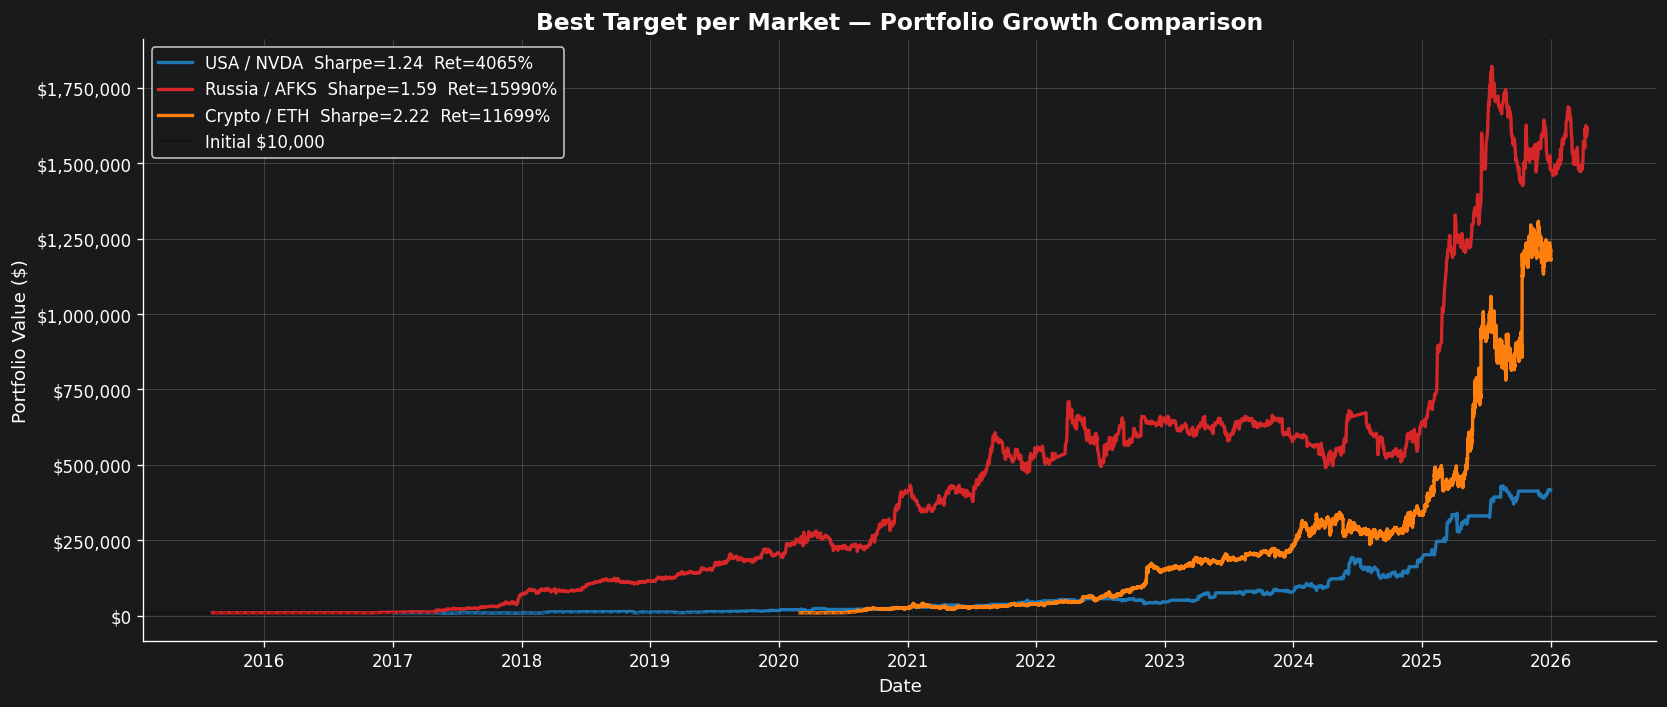

In [14]:
fig, ax = plt.subplots(figsize=(14, 6))

market_labels = {"usa": "USA", "russia": "Russia", "crypto": "Crypto"}
market_colors = {"usa": "#1f77b4", "russia": "#d62728", "crypto": "#ff7f0e"}

for market in ["usa", "russia", "crypto"]:
    # берём лучший таргет по Sharpe
    best_item = max(
        [(k, v) for k, v in pipeline_results.items() if k[0] == market],
        key=lambda x: x[1].backtest.metrics.sharpe_ratio,
        default=None,
    )
    if best_item is None:
        continue
    (mkt, target), result = best_item
    equity = result.backtest.equity_curve * INITIAL_CAPITAL
    m = result.backtest.metrics
    label = (
        f"{market_labels[market]} / {target}  "
        f"Sharpe={m.sharpe_ratio:.2f}  "
        f"Ret={m.total_return*100:.0f}%"
    )
    ax.plot(
        equity.index, equity,
        label=label,
        linewidth=2.0,
        color=market_colors[market],
    )

ax.axhline(
    INITIAL_CAPITAL, color="black", linestyle="--",
    linewidth=0.9, alpha=0.4, label=f"Initial ${INITIAL_CAPITAL:,.0f}",
)
ax.set_title("Best Target per Market — Portfolio Growth Comparison", fontsize=14, fontweight="bold")
ax.set_ylabel("Portfolio Value ($)", fontsize=11)
ax.set_xlabel("Date", fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.legend(fontsize=10, framealpha=0.92)
fig.tight_layout()
plt.show()